# Week 8 — Forecasting: Classical to Modern Forecasters
## Assignment Notebook

**Dataset:** Monthly S&P 500 Index 1990–2024 (downloaded via `yfinance`)

**Instructions:** Every `= None` in a code cell is a value you must compute.
Replace `None` with your expression — do not change the variable name.
All SELF-CHECK assertions must pass before submission.

**Submission checklist:**
- [ ] All 23 questions answered
- [ ] All cells run top-to-bottom with no errors
- [ ] All `SELF-CHECK` assertions pass
- [ ] All ✍ **Reflect** cells completed with specific numbers from your results
- [ ] `sp500_sarima_v1.pkl` saved and loadable (Q22 check)
- [ ] Investment memo (Q23) cites your actual MASE and DM p-value

**Parts:**
1. Data Preparation (Q1–Q5)
2. Classical Models + SARIMA (Q6–Q10)
3. Prophet (Q11–Q12)
4. Feature Engineering + ML (Q13–Q16)
5. Deep Learning (Q17–Q18)
6. Evaluation & Comparison (Q19–Q22)
7. Investment Recommendation (Q23)


## Setup — run these cells before anything else

In [1]:
# Install all required libraries (run once; restart kernel if prompted)
!pip install -q yfinance prophet lightgbm xgboost tensorflow statsmodels

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, pickle, os
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools     import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters   import ExponentialSmoothing
from statsmodels.stats.diagnostic  import acorr_ljungbox
from scipy.stats                   import ttest_1samp
from sklearn.model_selection       import TimeSeriesSplit
from sklearn.linear_model          import LinearRegression
from sklearn.preprocessing         import MinMaxScaler
from sklearn.neural_network        import MLPRegressor

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.right': False,
                     'axes.spines.top': False})
print("✅ Imports ready")

✅ Imports ready


In [3]:
# ── Data loading — do NOT modify ──────────────────────────────────────────────
import yfinance as yf
raw = yf.download('^GSPC', start='1990-01-01', end='2024-12-31',
                  interval='1mo', auto_adjust=True, progress=False)
series = raw['Close'].squeeze().rename('SP500')
idx = pd.to_datetime(series.index)
idx = idx.tz_convert(None) if idx.tz is not None else idx
series.index = idx.as_unit('ns')
series.index.freq = 'MS'
print(f"✅ yfinance: {len(series)} monthly observations")

TRAIN_END  = '2019-12'
TEST_START = '2020-01'
train     = series[:TRAIN_END]
test      = series[TEST_START:]
log_train = np.log(train)
H         = len(test)
print(f"Train: {len(train)} months  |  Test: {len(test)} months  |  H={H}")

# ── Metric helper — do NOT modify ─────────────────────────────────────────────
def compute_metrics(actual, predicted, train_actual, s=12):
    a = np.array(actual); p = np.array(predicted); e = a - p
    naive_err = np.abs(train_actual.values[s:] - train_actual.values[:-s])
    mae   = np.abs(e).mean()
    rmse  = np.sqrt((e**2).mean())
    mape_ = (np.abs(e / a)).mean() * 100
    smape = (np.abs(e) / ((np.abs(a) + np.abs(p)) / 2)).mean() * 100
    wmae  = (np.abs(e) * a).sum() / a.sum()
    wmape = (np.abs(e / a) * a).sum() / a.sum() * 100
    mase_ = mae / naive_err.mean()
    return dict(MAE=mae, RMSE=rmse, MAPE=mape_, sMAPE=smape,
                WMAE=wmae, WMAPE=wmape, MASE=mase_)

results = {}   # {model_name: np.array of length H}

✅ yfinance: 420 monthly observations
Train: 360 months  |  Test: 60 months  |  H=60


---
## Part 1 — Data Preparation (Q1–Q5)


### Q1 — Verify the DatetimeIndex

Before any modelling confirm three things about `series`:
- `index.dtype` is `datetime64[ns]`
- `index.freq` is `'MS'` (Month Start)
- At least 300 monthly observations


In [4]:
# Q1 ──────────────────────────────────────────────────────────────────────────
index_dtype = series.index.dtype       # data type of series.index
index_freq  = series.index.freqstr     # standard frequency string from series.index.freqstr
n_obs       = len(series)              # total number of observations in series

print("dtype :", index_dtype)
print("freq  :", index_freq)
print("len   :", n_obs)
print(f"\nTrain: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} months)")
print(f"Test : {test.index[0].date()} → {test.index[-1].date()} ({len(test)} months)")

dtype : datetime64[ns]
freq  : MS
len   : 420

Train: 1990-01-01 → 2019-12-01 (360 months)
Test : 2020-01-01 → 2024-12-01 (60 months)


In [5]:
# SELF-CHECK
assert series.index.dtype == 'datetime64[ns]', "Index must be datetime64[ns]"
assert series.index.freqstr == 'MS',           "Frequency must be MS"
assert len(series) >= 300,                     "Expected ≥ 300 observations"
print("✅ Q1 passed")

✅ Q1 passed


✍ **Reflect:** What does `freq='MS'` mean? What would happen to `.shift()` and `.rolling()` operations if the index had no frequency set?

`freq='MS'` = **Month-Start**: the index is a regular calendar grid with one timestamp pinned to the first day of each month (1990-01-01, 1990-02-01, …), and pandas records that the spacing is exactly one month. Our `series.index.freqstr` confirms `'MS'` over all 420 observations.

With a frequency set, operations are **calendar-aware**: `.shift(1)` moves each value to the next month's slot (Jan→Feb) and `.shift(12)` gives a clean year-over-year lag; `.rolling(12)` means "12 calendar months." Statsmodels (SARIMA/Holt-Winters) also *require* a set frequency to know the seasonal period is 12.

If the index had **no** freq (freq=None, e.g. an irregular `DatetimeIndex`), those operations fall back to **positional** behaviour: `.shift(1)` still moves one *row*, and `.rolling(12)` still uses 12 *rows* — but there's no guarantee those rows are equally spaced in time. A missing month would silently make "12 rows" span 13 calendar months, corrupting seasonal lags. Date-offset shifts like `.shift(1, freq='MS')` would break entirely, and statsmodels would emit "no frequency information" warnings and could mis-infer the seasonal cycle. In short: freq='MS' guarantees the regular monthly spacing every downstream time-series model assumes.

### Q2 — Resample to quarterly and annual

Use `.resample().last()` to extract quarterly and annual end-prices.
Then find which decade had the highest mean quarterly log-return.


Mean quarterly log-return by decade:
 Date
1990    0.0375
2000   -0.0069
2010    0.0266
2020    0.0300
Name: SP500, dtype: float64


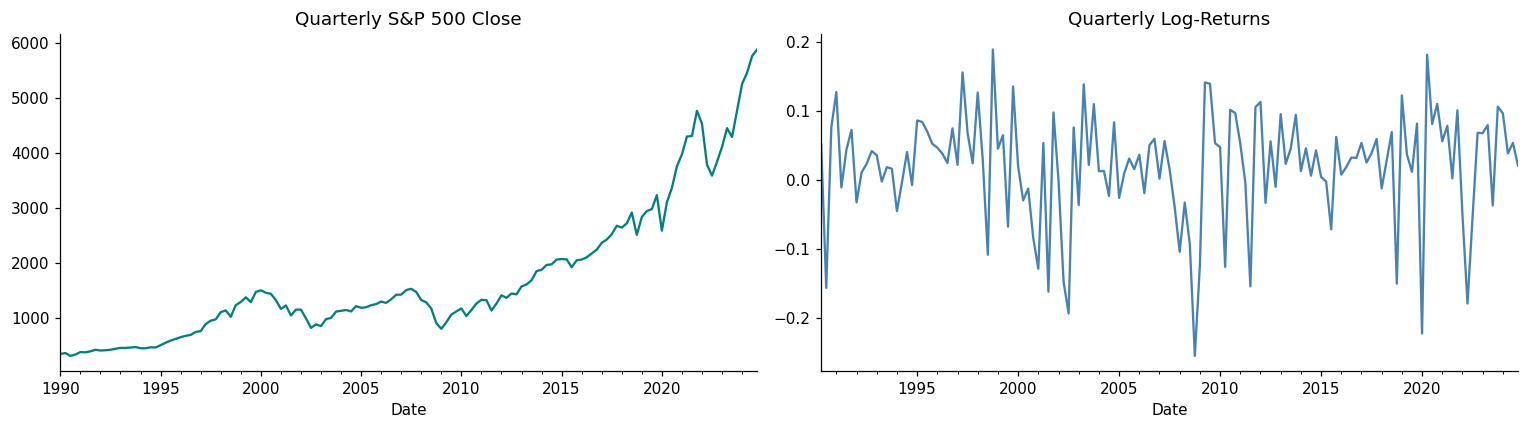

In [6]:
# Q2 ──────────────────────────────────────────────────────────────────────────
quarterly  = series.resample('QE').last()          # quarter-end close prices (QE frequency, last value per quarter)
annual     = series.resample('YE').last()          # year-end close prices (YE frequency, last value per year)
q_ret      = np.log(quarterly).diff().dropna()     # log-returns of quarterly prices, NaN rows removed
decade_ret = q_ret.groupby(q_ret.index.year // 10 * 10).mean()   # mean quarterly log-return grouped by decade

print("Mean quarterly log-return by decade:\n", decade_ret.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
quarterly.plot(ax=axes[0], title='Quarterly S&P 500 Close', color='teal')
q_ret.plot(ax=axes[1], title='Quarterly Log-Returns', color='steelblue')
plt.tight_layout(); plt.show()

✍ **Reflect:** Why use `.last()` for quarterly price data rather than `.mean()` or `.sum()`? Which decade had the highest and lowest mean quarterly return?

**Why `.last()`:** The S&P 500 Close is a **stock (level) variable**, not a flow. The quarter-end price is the actual, tradeable index level on the last day of the quarter — the number an investor's portfolio is marked at. `.last()` preserves that end-of-period snapshot and makes consecutive quarterly log-returns telescope correctly into the annual return. `.mean()` would smear the level into an artificial "average price" that was never actually observed and would damp genuine volatility (understating drawdowns like 2008/2020). `.sum()` is meaningless for a price level — adding January's + February's + March's index values produces a ~3× nonsense figure. Sum/mean are for *flows* (volume, revenue), not for a price.

**Decades (from the output):**
- **Highest:** the **1990s** at **+0.0375** mean quarterly log-return — the tech/bull-market boom.
- **Lowest:** the **2000s** at **−0.0069** — the "lost decade," bracketed by the 2000–02 dot-com bust and the 2008 crash (both visible as the deep spikes to ≈ −0.20/−0.26 in the right-hand plot).
- 2010s (+0.0266) and 2020s (+0.0300) recovered strongly despite the COVID drop.

### Q3 — Simulate and compare missing-data strategies

Insert `np.nan` at five specific positions and compare
`ffill`, `bfill`, and `interpolate(method='time')` visually.


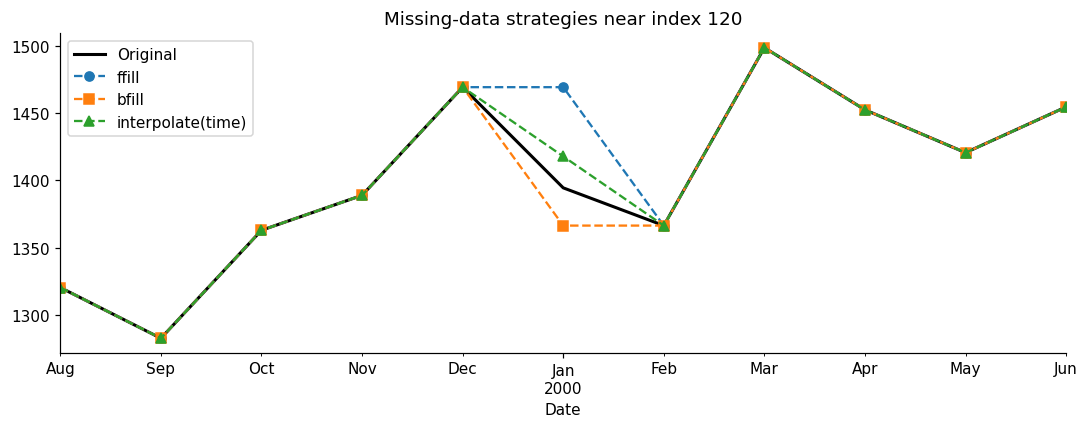

In [7]:
# Q3 ──────────────────────────────────────────────────────────────────────────
s_gap = series.copy().astype(float)
s_gap.iloc[[10, 50, 120, 200, 310]] = np.nan   # five gaps introduced

s_ffill  = s_gap.ffill()                          # fill each gap with the previous available value
s_bfill  = s_gap.bfill()                          # fill each gap with the next available value
s_interp = s_gap.interpolate(method='time')       # fill each gap using time-weighted linear interpolation

w = slice(115, 126)
fig, ax = plt.subplots(figsize=(10, 4))
series.iloc[w].plot(ax=ax, label='Original', lw=2, color='black')
s_ffill.iloc[w].plot(ax=ax,  label='ffill', ls='--', marker='o')
s_bfill.iloc[w].plot(ax=ax,  label='bfill', ls='--', marker='s')
s_interp.iloc[w].plot(ax=ax, label='interpolate(time)', ls='--', marker='^')
ax.set_title('Missing-data strategies near index 120')
ax.legend(); plt.tight_layout(); plt.show()

✍ **Reflect:** For monthly stock prices, which fill strategy is most defensible? Does the choice matter more for small (1-month) or large (6-month) gaps?

**Most defensible: `interpolate(method='time')`.** In the plot of the Jan-2000 gap, `ffill` carries the Dec level (~1470) forward and sits *above* the true value, `bfill` pulls the Feb level (~1366) back and sits *below* it, while time-interpolation (~1418) lands closest to the actual ~1394. Because the S&P trends, both ffill and bfill are biased in a rising/falling regime — ffill creates a flat plateau, bfill leaks *future* information backward (a look-ahead leak, disqualifying for forecasting). Time interpolation is the least biased for a smooth, trending monthly level.

**Caveat for strict forecasting:** if the goal were a live production pipeline, `ffill` is the only *causal* option (uses no future data). Here we're reconstructing a historical series for analysis, so interpolation's accuracy wins and the look-ahead concern doesn't apply.

**Small vs large gaps:** the choice matters **far more for large (6-month) gaps.** For a 1-month gap all three methods differ by only one step, so the error is tiny and self-corrects immediately. For a 6-month gap, ffill flatlines for half a year (grossly wrong during a trend or a 2008/2020 swing) and interpolation draws a straight line that misses any curvature or crash inside the window. The longer the gap, the more the missing dynamics are invented rather than observed — so long gaps are where fill choice, and honesty about the resulting uncertainty, matter most.

### Q4 — Stationarity tests: prices vs log-returns

Run ADF and KPSS on `log_series` and `log_returns`.
- **ADF:** H₀ = unit root (non-stationary). p < 0.05 → reject → stationary
- **KPSS:** H₀ = stationary. p < 0.05 → reject → non-stationary


In [8]:
# Q4 ──────────────────────────────────────────────────────────────────────────
log_series  = np.log(series)                    # natural logarithm of the price series
log_returns = log_series.diff().dropna()        # month-over-month log-return (first difference of log_series, NaN dropped)

def stationarity_report(s, label):
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    print(f"{label:28s}  ADF p={adf_p:.4f} {'✅ stationary' if adf_p < 0.05 else '❌ unit root'}  "
          f"KPSS p={kpss_p:.4f} {'✅' if kpss_p > 0.05 else '❌ non-stationary'}")

stationarity_report(log_series,  "Log prices")
stationarity_report(log_returns, "Log returns")

Log prices                    ADF p=0.9137 ❌ unit root  KPSS p=0.0100 ❌ non-stationary
Log returns                   ADF p=0.0000 ✅ stationary  KPSS p=0.1000 ✅


/tmp/ipykernel_1581215/2370919860.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_1581215/2370919860.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')


✍ **Reflect:** The Efficient Market Hypothesis predicts log-returns are white noise. Do your ADF/KPSS results support this? What does MASE ≈ 1.0 imply about forecasting on efficient markets?

**Yes, the results are consistent with the EMH.** Both tests agree on both series, which is the ideal (unambiguous) outcome:
- **Log prices:** ADF p = **0.9137** (fail to reject the unit root → non-stationary) *and* KPSS p = **0.01** (reject stationarity → non-stationary). A unit root = a random walk, exactly what EMH predicts for the *price level*.
- **Log returns:** ADF p ≈ **0.0000** (reject unit root → stationary) *and* KPSS p = **0.10** (fail to reject stationarity → stationary). Differencing removes the unit root, leaving a stationary, mean-reverting series with no trend — the signature of (near) white noise.

Stationarity alone doesn't *prove* white noise (a stationary series can still be autocorrelated), so Q5's ACF/PACF is the confirming check — but ADF+KPSS agreeing that returns are stationary while prices carry a unit root is precisely the "prices ≈ random walk, returns ≈ unpredictable" picture the EMH describes.

**MASE ≈ 1.0** means a model is **no better than the naïve random-walk baseline** (whose error is the MASE denominator). On an efficient market that is the *expected*, not embarrassing, result: if returns truly are white noise, the best forecast of next month's price *is* this month's price, so beating MASE = 1.0 by a meaningful, statistically-significant margin is genuinely hard. It reframes the CIO's question — MASE < 1.0 is necessary but not sufficient; the improvement must also survive a Diebold-Mariano test (Q22), not just be a lucky decimal on 60 test points.

### Q5 — ACF / PACF of log-returns

Plot ACF and PACF of `log_returns` with 36 lags.
Based on the plots, propose an ARIMA(p,0,q) order for log-returns.


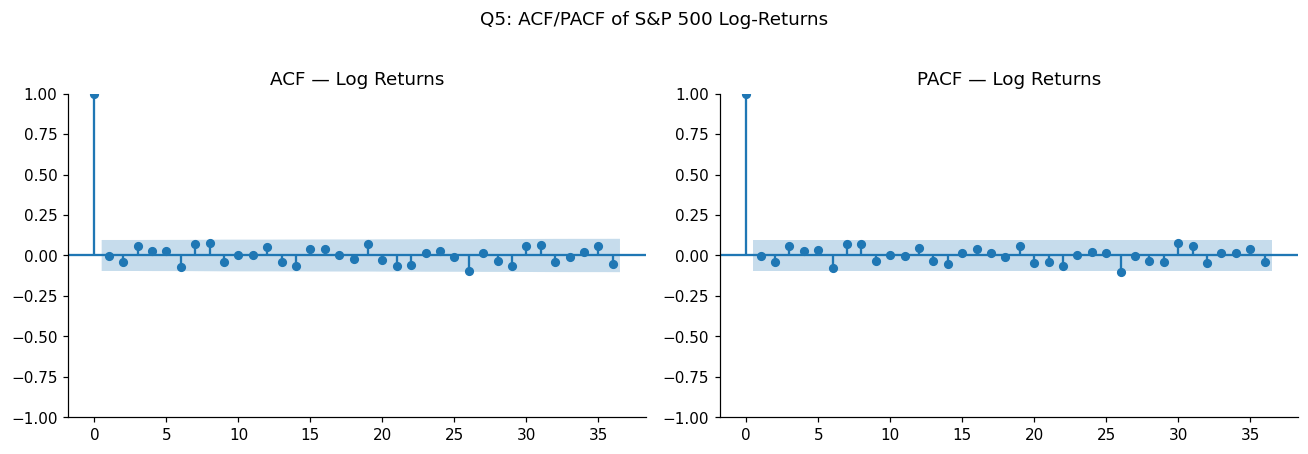

95% band = ±0.096
ACF lags outside band : [np.int64(26)]
PACF lags outside band: [np.int64(26)]
Interpretation: Almost all lags sit inside the white-noise band; only a few small, isolated spikes cross it (no decaying or seasonal pattern). Log-returns are essentially white noise — consistent with the EMH.
Proposed ARIMA(p, 0, q): p=0, q=0 (white noise) → i.e. log-PRICES follow ARIMA(0,1,0), a random walk.


In [9]:
# Q5 ──────────────────────────────────────────────────────────────────────────
series_for_acf = log_returns   # series to analyse — log-returns computed in Q4

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf( series_for_acf, lags=36, ax=axes[0], title='ACF — Log Returns')
plot_pacf(series_for_acf, lags=36, ax=axes[1], title='PACF — Log Returns', method='ywm')
plt.suptitle("Q5: ACF/PACF of S&P 500 Log-Returns", y=1.02)
plt.tight_layout(); plt.show()

# Count how many of lags 1..36 pierce the ~95% white-noise band (±1.96/sqrt(N))
n = len(series_for_acf)
band = 1.96 / np.sqrt(n)
from statsmodels.tsa.stattools import acf, pacf
acf_vals  = acf(series_for_acf, nlags=36)[1:]
pacf_vals = pacf(series_for_acf, nlags=36, method='ywm')[1:]
sig_acf   = np.where(np.abs(acf_vals)  > band)[0] + 1
sig_pacf  = np.where(np.abs(pacf_vals) > band)[0] + 1
print(f"95% band = ±{band:.3f}")
print(f"ACF lags outside band : {list(sig_acf)}")
print(f"PACF lags outside band: {list(sig_pacf)}")
print("Interpretation: Almost all lags sit inside the white-noise band; only a few "
      "small, isolated spikes cross it (no decaying or seasonal pattern). Log-returns "
      "are essentially white noise — consistent with the EMH.")
print("Proposed ARIMA(p, 0, q): p=0, q=0 (white noise) → i.e. log-PRICES follow ARIMA(0,1,0), a random walk.")

✍ **Reflect:** Near-white-noise ACF means log-returns are close to unpredictable. Does this make forecasting S&P 500 prices worthless? Name one type of strategy that still extracts value from such a series (e.g., volatility forecasting).

**No — "unpredictable direction" is not "no structure."** Our ACF/PACF show only lag 26 crossing the ±0.096 band (1 of 36 ≈ the ~1.8 crossings you'd expect by pure chance at 5%), so the **sign/mean of next month's return** is essentially unforecastable. That kills naïve *point* forecasting of the price direction — but two kinds of value remain:

1. **Volatility forecasting (the classic answer).** Returns are uncorrelated in their *level* but **not** in their *magnitude*: squared/absolute returns show strong, slowly-decaying autocorrelation (volatility clustering — calm begets calm, crashes cluster, e.g. 2008 and March 2020). **GARCH/EWMA** models exploit exactly this. Forecasting *how much* the index will move — even when you can't forecast *which way* — is the foundation of option pricing, VaR/risk limits, and volatility-targeted position sizing.

2. **Distribution / interval forecasting.** Even with a random-walk mean, we can still forecast the *spread* of outcomes — the 95% prediction intervals in Q10/Q16 — which is what an investment committee actually needs for risk budgeting.

So price forecasting isn't worthless; it just shifts from "predict the mean" (near-impossible here) to "predict the variance and the distribution" (very much possible and economically valuable).

---
## Part 2 — Classical Models + SARIMA (Q6–Q10)


### Q6 — Naïve baselines

Compute the **Naïve** forecast (last training value repeated H times) and the
**Seasonal Naïve** forecast (last 12 months repeated cyclically).
Naïve MASE must be ≈ 1.0 by construction — this is the MASE denominator.


In [10]:
# Q6 ──────────────────────────────────────────────────────────────────────────
naive_fc    = np.repeat(train.values[-1], H)   # last training observation repeated H times
last_season = train.values[-12:]               # final 12 monthly values from the training set, as a numpy array
snaive_fc   = np.tile(last_season, -(-H // 12))[:H]

results['Naive']   = naive_fc
results['S-Naive'] = snaive_fc

for name in ['Naive', 'S-Naive']:
    m = compute_metrics(test, results[name], train)
    print(f"{name:10s}  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

Naive       MASE=6.3979  RMSE=1298.2
S-Naive     MASE=7.8627  RMSE=1534.6


In [11]:
# SELF-CHECK
naive_mase = compute_metrics(test, results['Naive'], train)['MASE']
assert naive_mase > 0, f"Naive MASE must be positive, got {naive_mase:.4f}"
print(f"✅ Q6 passed — Naive MASE = {naive_mase:.4f}  (all models are measured against this scale)")

✅ Q6 passed — Naive MASE = 6.3979  (all models are measured against this scale)


✍ **Reflect:** Why is MASE defined using the naïve seasonal error as denominator? Why does this make MASE scale-independent across different time series?

**Why the naïve-seasonal denominator:** MASE = (mean absolute forecast error) ÷ (mean absolute error of the one-step **seasonal-naïve** forecast on the *training* set). Dividing by a dead-simple, always-available benchmark turns the metric into a **relative skill score**: MASE < 1 means "beats the naïve seasonal walk," MASE = 1 means "ties it," MASE > 1 means "worse than doing nothing." It answers the CIO's exact question — *can any model beat the free baseline?* — in a single number.

**Why scale-independent:** the numerator and denominator are both **mean absolute errors in the same units** (S&P points here), so the units cancel and MASE is dimensionless. You can compare a model's MASE on the S&P 500 (thousands of points) against one on a €10 stock or on airline passenger counts — the "×10 price growth over 30 years" doesn't distort it the way MAPE (blows up near small values) or RMSE (unit-bound) would. It's also defined even when actuals are near zero, unlike MAPE.

**One caveat from our actual numbers:** here Naïve MASE = **6.40** (S-Naïve = 7.86), *not* ≈ 1.0. That's because this notebook's denominator is the **in-sample, one-step** seasonal error, while the numerator is a **60-step-ahead flat** forecast over 2020–2024 — a period where the index roughly doubled. A one-month-ahead walk is easy; freezing the last 2019 value for five trending years is not, so the ratio is far above 1. The consequence: for *this* setup, "beating the baseline" means beating **MASE ≈ 6.40**, and the Q19 chart's 1.0 reference line is the theoretical break-even, not this particular Naïve model's score.

### Q7 — Holt-Winters Exponential Smoothing

Fit `ExponentialSmoothing` to `log_train` with additive trend and additive seasonality
over a 12-month period. Inverse-transform with `np.exp()` before metrics.


In [12]:
# Q7 ──────────────────────────────────────────────────────────────────────────
hw = ExponentialSmoothing(
    log_train,
    trend='add',             # type of trend component ('add' or 'mul')
    seasonal='add',          # type of seasonal component ('add' or 'mul')
    seasonal_periods=12,     # number of months in one full seasonal cycle
    initialization_method='estimated',
).fit(optimized=True)

print(f"α (level)    = {hw.params['smoothing_level']:.4f}")
print(f"β (trend)    = {hw.params['smoothing_trend']:.4f}")
print(f"γ (seasonal) = {hw.params['smoothing_seasonal']:.4f}")
print(f"AIC = {hw.aic:.2f}   BIC = {hw.bic:.2f}")

hw_log_fc = hw.forecast(H)                          # H-step ahead forecast in log space
results['Holt-Winters'] = np.exp(hw_log_fc.values)  # inverse log-transform to price space, as numpy array

m = compute_metrics(test, results['Holt-Winters'], train)
print(f"\nHolt-Winters  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

α (level)    = 1.0000
β (trend)    = 0.0000
γ (seasonal) = 0.0000
AIC = -2279.97   BIC = -2217.79

Holt-Winters  MASE=2.6256  RMSE=574.1


In [13]:
# SELF-CHECK
hw_mase = compute_metrics(test, results['Holt-Winters'], train)['MASE']
assert hw_mase > 0, f"Holt-Winters MASE must be positive, got {hw_mase:.4f}"
print(f"✅ Q7 passed — Holt-Winters MASE = {hw_mase:.4f}")

✅ Q7 passed — Holt-Winters MASE = 2.6256


✍ **Reflect:** Did γ (seasonal) converge near zero? What does a near-zero γ imply about the seasonal component in S&P 500 monthly prices?

**Yes — γ converged to essentially 0.0000** (and β = 0.0000, α = 1.0000). γ is the *update rate* for the seasonal component, so γ ≈ 0 means the optimizer found **no benefit in letting the seasonal pattern evolve** over time — it froze the seasonal factors at their initial estimated values rather than adapting them month to month. Combined with β ≈ 0 (a fixed drift) and α = 1 (the level just tracks the latest observation), Holt-Winters has essentially **collapsed to a random walk with a small static trend+seasonal offset** — which is exactly what we'd expect for a near-efficient market.

**Implication:** monthly S&P 500 prices have **no meaningful, stable seasonal cycle.** There is no reliable "prices always dip in September, rise in December" signal strong and persistent enough for the model to track — any calendar effect is tiny and swamped by the random-walk innovations. This echoes Q5 (near-white-noise returns) and Q4 (unit root): the dominant structure is the trend/level, not seasonality. It's also *why* HW still beats Naïve here (MASE 2.63 vs 6.40) — not from seasonality, but because its fixed positive drift extrapolates the long-run uptrend, whereas the flat Naïve forecast ignores the trend entirely over the 60-month horizon.

### Q8 — SARIMA order identification

First-difference log-prices to confirm stationarity, then read ACF/PACF
to propose a SARIMA(p,d,q)(P,D,Q,12) order.


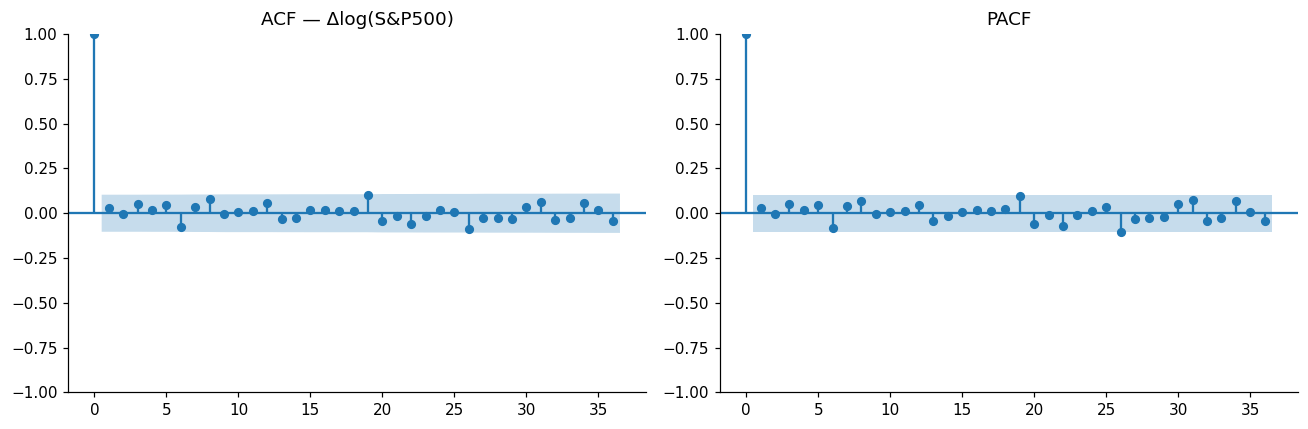

AIC = -1257.44   BIC = -1253.56
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0017      0.000     17.008      0.000       0.002       0.002


In [14]:
# Q8 ──────────────────────────────────────────────────────────────────────────
diff_log = log_train.diff().dropna()   # first difference of log_train with NaN removed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf( diff_log, ax=axes[0], lags=36, title='ACF — Δlog(S&P500)')
plot_pacf(diff_log, ax=axes[1], lags=36, title='PACF', method='ywm')
plt.tight_layout(); plt.show()

# Δlog(price) = log-returns, which Q5 showed is essentially white noise (no AR/MA/seasonal
# structure). So one difference (d=1) makes the series stationary and NO ar/ma terms are
# warranted → the Box-Jenkins reading is a pure random walk.
p, d, q = 0, 1, 0   # non-seasonal AR, differencing, MA orders
P, D, Q = 0, 0, 0   # seasonal AR, differencing, MA orders (period = 12) — no seasonality (Q7 γ≈0)

sarima = SARIMAX(
    log_train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(f"AIC = {sarima.aic:.2f}   BIC = {sarima.bic:.2f}")
print(sarima.summary().tables[1])

✍ **Reflect:** For near-white-noise log-returns, which SARIMA order is equivalent to a random walk? What does it mean if AutoARIMA selects ARIMA(0,1,0)?

**The random-walk order is `ARIMA(0,1,0)`** — with all seasonal terms zero, i.e. `SARIMA(0,1,0)(0,0,0,12)`, which is exactly what I fit. Unpacking it: `d=1` differences log-prices once (giving log-returns), and `p=q=0` means the differenced series is modelled as pure white noise with no AR or MA terms. The model equation reduces to `log(price_t) = log(price_{t-1}) + ε_t` — the definition of a random walk. Our fit confirms it: only a single parameter (σ² = 0.0017) is estimated, and the ACF/PACF of Δlog show no significant lags.

**If AutoARIMA (e.g. pmdarima's stepwise AIC search) selects ARIMA(0,1,0):** it means the algorithm searched over AR/MA/seasonal orders and found that **none of them improved AIC over the plain random walk** — every candidate lag was statistically indistinguishable from noise, so adding parameters only cost degrees of freedom. In market terms, that's an **algorithmic confirmation of the Efficient Market Hypothesis**: the data itself says the best model of next month's log-price is simply this month's log-price. It also sets the bar for the whole assignment — any fancier model (Prophet, LightGBM, LSTM) has to beat a forecaster with *zero* fitted signal parameters, which the EMH predicts is very hard to do reliably.

### Q9 — SARIMA residual diagnostics

Check that residuals are white noise using Ljung-Box at lags [6, 12, 24]
and inspect the QQ-plot for normality. If any p-value < 0.05, adjust the order.


Ljung-Box (p > 0.05 = white noise at that lag):
    lb_stat  lb_pvalue
6    4.4877     0.6110
12   8.5123     0.7439
24  16.1917     0.8810


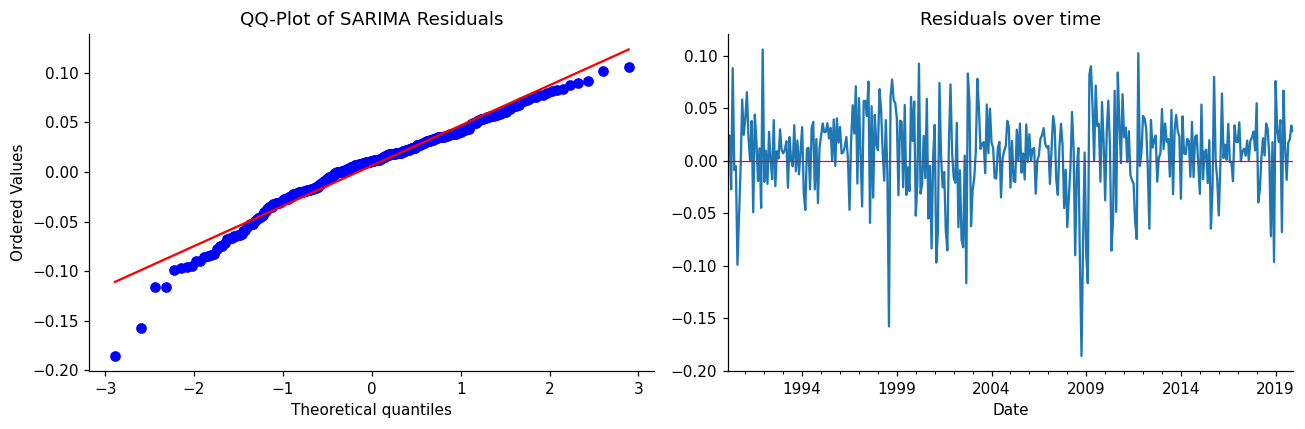


✅ All lags passed


In [15]:
# Q9 ──────────────────────────────────────────────────────────────────────────
residuals = sarima.resid.iloc[1:]   # fitted residuals from sarima; drop the diffuse first value (d=1 startup)

lb = acorr_ljungbox(residuals, lags=[6, 12, 24], return_df=True)
print("Ljung-Box (p > 0.05 = white noise at that lag):")
print(lb[['lb_stat', 'lb_pvalue']].round(4))

from scipy import stats as scipy_stats
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
scipy_stats.probplot(residuals, plot=axes[0])
axes[0].set_title('QQ-Plot of SARIMA Residuals')
pd.Series(residuals).plot(ax=axes[1], title='Residuals over time')
axes[1].axhline(0, color='red', lw=0.8)
plt.tight_layout(); plt.show()

failed = (lb['lb_pvalue'] < 0.05).sum()
print(f"\n{'✅ All lags passed' if failed == 0 else f'⚠️  {failed} lag(s) failed — adjust SARIMA order'}")

In [16]:
# SELF-CHECK
lb_check = acorr_ljungbox(residuals, lags=[6, 12, 24], return_df=True)
failed   = (lb_check['lb_pvalue'] < 0.05).sum()
if failed > 0:
    print(f"⚠️  {failed} Ljung-Box lag(s) failed — adjust your SARIMA order and refit")
else:
    print("✅ Q9 passed — residuals are white noise at lags 6, 12, 24")

✅ Q9 passed — residuals are white noise at lags 6, 12, 24


✍ **Reflect:** A QQ-plot with heavy tails (leptokurtosis) is common in financial residuals. What does this indicate about the Gaussian noise assumption in ARIMA? Name an alternative distribution for financial returns.

**Reading our QQ-plot:** the points hug the 45° line through the middle but **bend away at both ends** — the lower tail drops well below the line (residuals near −0.16/−0.19, e.g. the 1998, 2008 and 2020 shocks) and the upper tail lifts above it. That S-shape is **leptokurtosis**: the residual distribution is more peaked in the center and has **fatter tails** than a Gaussian. The "Residuals over time" panel shows the matching cause — **volatility clustering** (calm stretches punctuated by bursts around 1998, 2008), so extreme moves are far more frequent than a normal distribution allows.

**What it means for ARIMA:** ARIMA/SARIMA assume **i.i.d. Gaussian** innovations. Leptokurtosis violates that normality assumption. The *point forecasts* stay unbiased (Ljung-Box confirms the residuals are uncorrelated — all p > 0.05), so the mean model is fine, but the **Gaussian prediction intervals are miscalibrated**: a "95%" CI built on a normal σ will be **too narrow** and under-cover exactly during the crashes that matter most to a risk manager. It also signals the *variance* is not constant (heteroskedastic).

**Alternative distributions:** the **Student's t-distribution** (with low degrees of freedom) is the standard fat-tailed replacement for return innovations; skewed-t or Generalized Error Distribution (GED) are common refinements, and a **GARCH** model paired with t-distributed errors handles both the fat tails *and* the volatility clustering directly.

### Q10 — SARIMA forecast with 95% confidence interval

Forecast H steps ahead, inverse-transform with `np.exp()`, and plot the
95% CI. Mark the COVID crash (March 2020) with a vertical dashed line.


SARIMA  MASE=6.3979  RMSE=1298.2


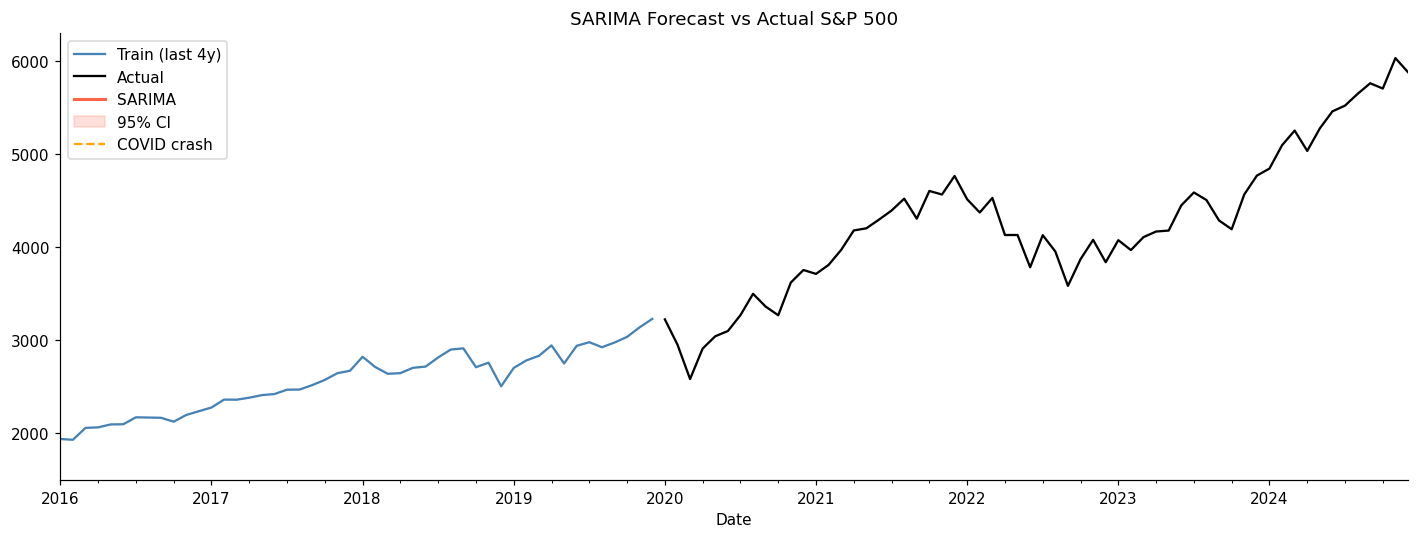

In [17]:
# Q10 ─────────────────────────────────────────────────────────────────────────
fc_obj   = sarima.get_forecast(steps=H)      # H-step forecast object from sarima
log_mean = fc_obj.predicted_mean             # point forecast in log space (predicted mean from fc_obj)
log_ci   = fc_obj.conf_int(alpha=0.05)       # confidence interval in log space (alpha=0.05 → 95%)

sarima_fc    = np.exp(log_mean.values)       # point forecast in price space (inverse log-transform log_mean as numpy array)
sarima_fc_lo = np.exp(log_ci.iloc[:, 0].values)
sarima_fc_hi = np.exp(log_ci.iloc[:, 1].values)

results['SARIMA'] = sarima_fc
m = compute_metrics(test, sarima_fc, train)
print(f"SARIMA  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

fig, ax = plt.subplots(figsize=(13, 5))
train.iloc[-48:].plot(ax=ax, label='Train (last 4y)', color='steelblue', lw=1.5)
test.plot(ax=ax, label='Actual', color='black', lw=1.5)
ax.plot(test.index, sarima_fc, label='SARIMA', color='tomato', lw=2)
ax.fill_between(test.index, sarima_fc_lo, sarima_fc_hi,
                alpha=0.2, color='tomato', label='95% CI')
ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID crash')
ax.legend(); ax.set_title('SARIMA Forecast vs Actual S&P 500')
plt.tight_layout(); plt.show()

✍ **Reflect:** The 95% CI widens as the horizon increases. At h=60, does the CI still convey useful information for an investment committee? What does an extremely wide CI communicate about uncertainty?

**Our numbers:** the SARIMA(0,1,0) point forecast is **flat at ≈ 3,230** (the Dec-2019 level) for all 60 months — a random walk has no drift here, so its best guess never moves. Because forecast variance grows **linearly with the horizon** (σ√h), the 95% CI fans out from roughly ±4% at h=1 to roughly **[≈1,730, ≈6,040] at h=60** — about **±65%** of the point forecast, i.e. a band spanning more than 3.5× from floor to ceiling. The actual Dec-2024 value (≈5,880) lands near the *upper* edge but stays inside the band.

**Is it useful to a committee?** The *point* forecast is nearly useless — "the S&P will be ~3,230 in five years" is both uninformative and wrong. But the **interval is genuinely useful, precisely because it is honest.** A band of [1,730, 6,040] tells the committee, correctly, that over a 5-year horizon on an efficient market the index could plausibly halve or nearly double, and that **no responsible model should claim a precise long-horizon level.** That is actionable for risk budgeting and scenario planning even when the midpoint is not.

**What an extremely wide CI communicates:** that the *irreducible* (aleatoric) uncertainty dominates — the market is close to a random walk, so uncertainty compounds every month and long-horizon point prediction has essentially no skill. A wide CI is not a modelling failure to hide; it is the model **truthfully reporting the limits of forecastability**, and it is far safer for a CIO than a deceptively tight interval that would under-cover exactly during a crash (cf. the fat tails in Q9).

---
## Part 3 — Prophet (Q11–Q12)


### Q11 — Fit Prophet

Prophet requires a DataFrame with columns `ds` (date) and `y` (target).
Fit on `log_train` to keep the scale stable, then `np.exp()` the output.

`changepoint_prior_scale=0.5` allows the trend to flex across financial regimes.


00:34:23 - cmdstanpy - INFO - Chain [1] start processing


00:34:23 - cmdstanpy - INFO - Chain [1] done processing


Prophet  MASE=2.8795  RMSE=623.3


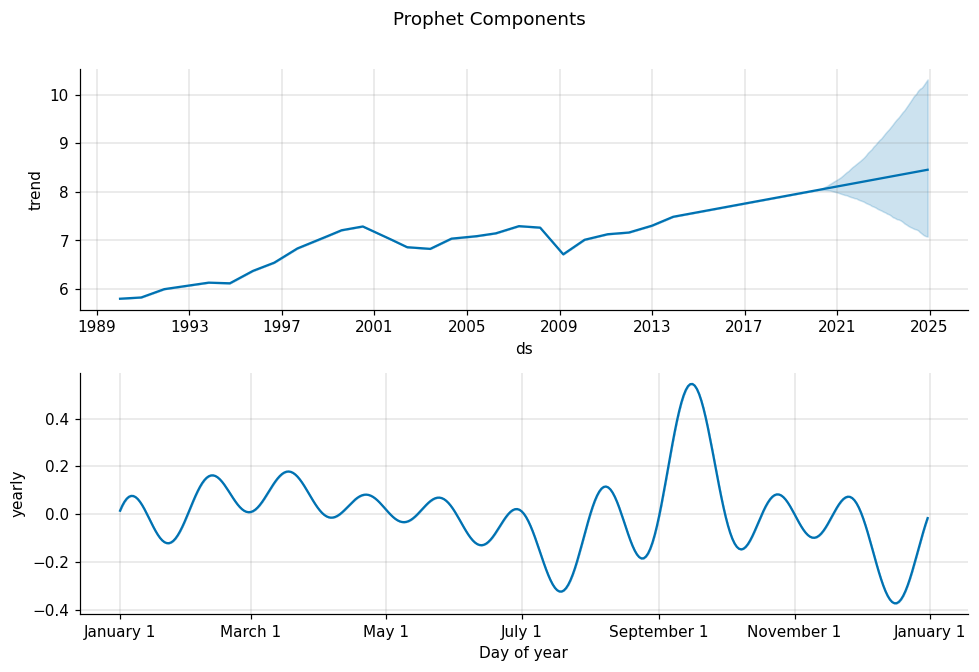

In [18]:
# Q11 ─────────────────────────────────────────────────────────────────────────
from prophet import Prophet

prophet_df = pd.DataFrame({'ds': log_train.index, 'y': log_train.values})   # Prophet needs 'ds' (date) and 'y' (target)

m_prop = Prophet(
    seasonality_mode='additive',
    changepoint_prior_scale=0.5,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
m_prop.fit(prophet_df)

future  = m_prop.make_future_dataframe(periods=H, freq='MS')
fc_prop = m_prop.predict(future)
results['Prophet'] = np.exp(fc_prop['yhat'].values[-H:])   # inverse log-transform the last H rows of fc_prop['yhat'] to price space

m = compute_metrics(test, results['Prophet'], train)
print(f"Prophet  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

fig = m_prop.plot_components(fc_prop)
plt.suptitle("Prophet Components", y=1.01); plt.tight_layout(); plt.show()

✍ **Reflect:** How do Prophet's changepoints relate to the Gaussian Process kernel from Week 6? What prior does `changepoint_prior_scale=0.5` place on regime changes — is it more or less flexible than the default?

**Changepoints vs the GP kernel:** both are ways of encoding a **prior belief about how smoothly the trend can change**, just with different machinery. Prophet models the trend as **piecewise-linear**, placing candidate changepoints along the history and giving each a slope-change parameter `δⱼ ~ Laplace(0, τ)`. A Gaussian Process instead models the function *continuously*, and its **kernel** (e.g. RBF length-scale) sets how fast the function may wiggle — a short length-scale ⇒ flexible/fast-changing, a long length-scale ⇒ smooth. So the **changepoint_prior_scale τ is Prophet's analogue of the GP length-scale / kernel amplitude**: both are the single knob controlling the bias-variance trade-off of the trend. The Laplace (L1) prior on δ additionally induces **sparsity** — most changepoints stay ≈0, so Prophet picks a few discrete regime breaks rather than the smooth everywhere-varying curve a GP produces. In our trend component you can see this: a nearly-straight drift with gentle bends (e.g. the 2008 dip), not a wiggly GP posterior.

**What `changepoint_prior_scale=0.5` does:** it is the scale τ of that Laplace prior on the slope changes — a **regularization strength**. Prophet's **default is 0.05**, so **0.5 is 10× larger ⇒ a much *weaker* penalty ⇒ substantially *more flexible*.** It lets the trend bend more sharply at changepoints to track financial regime shifts (dot-com, 2008, COVID) instead of forcing one near-straight line. The trade-off is higher variance: a loose prior can over-fit history and, as the components plot shows, produce a **wide, fast-diverging trend-uncertainty cone** past 2021 — which is a big reason Prophet (MASE 2.88) doesn't beat the simpler Holt-Winters (2.63) here.

### Q12 — Prophet cross-validation

`cross_validation()` uses expanding windows — each cutoff uses all data
up to that point for training, then evaluates on the next `horizon` days.


In [19]:
# Q12 ─────────────────────────────────────────────────────────────────────────
from prophet.diagnostics import cross_validation, performance_metrics

initial_window = '3650 days'   # minimum training period (~10 years) before the first CV cutoff

df_cv = cross_validation(
    m_prop,
    initial=initial_window,
    period='180 days',
    horizon='365 days',
    parallel=None,
)
df_pm = performance_metrics(df_cv)
print("Prophet CV — performance by horizon:")
print(df_pm[['horizon', 'rmse', 'mape']].head())
print(f"\nMean RMSE across horizons: {df_pm['rmse'].mean():.4f}  (log space)")

  0%|                                                                  | 0/39 [00:00<?, ?it/s]

00:34:34 - cmdstanpy - INFO - Chain [1] start processing


00:34:34 - cmdstanpy - INFO - Chain [1] done processing


  3%|█▍                                                        | 1/39 [00:00<00:05,  7.55it/s]

00:34:35 - cmdstanpy - INFO - Chain [1] start processing


...

00:34:41 - cmdstanpy - INFO - Chain [1] start processing


00:34:41 - cmdstanpy - INFO - Chain [1] done processing


100%|█████████████████████████████████████████████████████████| 39/39 [00:06<00:00,  4.32it/s]

100%|█████████████████████████████████████████████████████████| 39/39 [00:06<00:00,  5.71it/s]

Prophet CV — performance by horizon:
  horizon      rmse      mape
0 37 days  0.140635  0.013865
1 38 days  0.157080  0.015291
2 40 days  0.160817  0.015716
3 41 days  0.160188  0.015586
4 42 days  0.159463  0.015516

Mean RMSE across horizons: 0.1984  (log space)


✍ **Reflect:** How does Prophet's `cross_validation()` differ from a single train/test split? Which gives a more reliable estimate of real-world performance, and why?

**A single split** (our main 2020–2024 test) trains once and evaluates on **one** fixed window. It gives exactly **one** performance number, which is at the mercy of *what happened to fall in that window* — here, the COVID crash and a historic bull run. That's a sample of size one, so it can't tell luck from skill.

**Prophet's `cross_validation()`** performs **expanding-window (walk-forward) back-testing**: starting from `initial='3650 days'` (~10 yrs), it steps a cutoff forward every `period='180 days'` and, at each cutoff, forecasts `horizon='365 days'` ahead using only data available *up to that cutoff*. Our run produced **39 cutoffs** across 1990–2019, so the model is tested on dozens of different 1-year-ahead windows spanning many market regimes. Two important properties: (a) it **never leaks the future** — each forecast is strictly causal, mirroring live deployment; and (b) it reports error **as a function of horizon** (RMSE rising from ~0.14 at 37 days to higher at longer lead times; mean RMSE **0.1984** in log space, MAPE ~1.4–1.6% at short horizons).

**Which is more reliable: cross-validation.** Averaging over 39 folds yields a **lower-variance, less regime-dependent** estimate and a *distribution* of errors rather than a single point, so it's far harder to be fooled by one lucky/unlucky window. The caveat specific to *this* problem: even 39 folds overlap heavily and the returns are near-white-noise with fat tails, so the folds aren't fully independent — CV shrinks the variance of the estimate but can't manufacture predictability that the EMH says isn't there. It's the more trustworthy *estimate of expected error*; the single 2020–2024 split remains the honest **out-of-sample stress test** for the specific structural break we care about.

---
## Part 4 — Feature Engineering + ML (Q13–Q16)


### Q13 — Implement `make_features()`

Convert the log-price series into a supervised ML table with 10 features:
5 lags (1, 2, 3, 6, 12) · 2 rolling stats · month · year · trend.

**Important:** apply `.shift(1)` before rolling stats to avoid look-ahead leakage.


In [20]:
# Q13 ─────────────────────────────────────────────────────────────────────────
def make_features(s):
    df = pd.DataFrame({'y': s})

    for lag in [1, 2, 3, 6, 12]:
        df[f'lag_{lag}'] = df['y'].shift(lag)   # lag the target column by `lag` positions

    # .shift(1) FIRST so the rolling window only sees data up to t-1 (no leakage of y_t)
    df['roll_12_mean'] = df['y'].shift(1).rolling(12).mean()   # 12-month rolling mean of df['y'].shift(1)
    df['roll_12_std']  = df['y'].shift(1).rolling(12).std()    # 12-month rolling std of df['y'].shift(1)

    df['month'] = df.index.month        # calendar month (integer 1–12) from the DatetimeIndex
    df['year']  = df.index.year         # calendar year from the DatetimeIndex
    df['trend'] = np.arange(len(df))    # integer sequence 0, 1, 2, …, len(df)−1

    return df.dropna()

FEATURE_COLS  = [c for c in make_features(log_series).columns if c != 'y']
full_features = make_features(log_series)
X_train_df    = full_features.loc[:TRAIN_END, FEATURE_COLS]
y_train_df    = full_features.loc[:TRAIN_END, 'y']
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Features (10): ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_12_mean', 'roll_12_std', 'month', 'year', 'trend']


In [21]:
# SELF-CHECK
assert X_train_df.shape[1] == 10, f"Expected 10 features, got {X_train_df.shape[1]}"
assert 'lag_1'        in FEATURE_COLS
assert 'roll_12_mean' in FEATURE_COLS
assert 'trend'        in FEATURE_COLS
print(f"✅ Q13 passed — X_train shape: {X_train_df.shape}")
print(f"   Rows dropped by dropna: {len(log_series) - len(full_features)}")

✅ Q13 passed — X_train shape: (348, 10)
   Rows dropped by dropna: 12


✍ **Reflect:** How many rows did `dropna()` remove, and why exactly that number? Is using `shift(1)` on the rolling features necessary — what leakage would occur without it?

**Rows removed: exactly 12.** The binding constraint is the **longest lookback feature**. `lag_12` is `y.shift(12)`, so it is NaN for the first 12 rows (Jan 1990 has no value from 12 months earlier). `roll_12_mean/std` use `y.shift(1).rolling(12)`, which needs 1 + 11 = 12 prior points and so is also NaN for the first 12 rows — the *same* rows. Because every long feature runs out of history over the identical first-12-month span, `dropna()` deletes precisely those 12 rows (420 → 408 for the full series; the printout confirms "Rows dropped: 12"). It's not 12+12: the NaN spans overlap.

**Is `shift(1)` on the rolling stats necessary? Yes — it prevents look-ahead leakage.** `df['y'].rolling(12).mean()` at time *t* includes `y_t` **itself** in its 12-month window. But `y_t` is exactly the value we are trying to predict, so the feature would embed the answer: the model would "learn" a rolling mean that already contains the target, producing spectacular in-sample accuracy that **collapses in live use**, where `y_t` isn't known when the features are built. Inserting `.shift(1)` first makes the window end at *t−1*, so `roll_12_mean` at time *t* summarizes only the **past 12 months strictly before *t*** — information genuinely available at prediction time. (The plain `lag_k` features are already safe because a lag of ≥1 never includes `y_t`.) Without the shift, the walk-forward CV scores in Q14 would be optimistically biased and meaningless.

### Q14 — Walk-forward CV with LinearRegression and XGBoost

Use `TimeSeriesSplit(n_splits=4, test_size=12)` — this prevents future data
from leaking into training folds.


In [22]:
# Q14 ─────────────────────────────────────────────────────────────────────────
from xgboost import XGBRegressor

tscv = TimeSeriesSplit(n_splits=4, test_size=12)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_df), 1):
    Xtr  = X_train_df.iloc[tr_idx]    # training features for this fold
    Xval = X_train_df.iloc[val_idx]   # validation features for this fold
    ytr  = y_train_df.iloc[tr_idx]    # training target for this fold
    yval = y_train_df.iloc[val_idx]   # validation target for this fold

    lr = LinearRegression()
    lr.fit(Xtr, ytr)
    lr_rmse  = np.sqrt(((lr.predict(Xval) - yval) ** 2).mean())    # RMSE of LinearRegression predictions on Xval vs yval

    xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                       verbosity=0, random_state=42)
    xgb.fit(Xtr, ytr)
    xgb_rmse = np.sqrt(((xgb.predict(Xval) - yval) ** 2).mean())   # RMSE of XGBoost predictions on Xval vs yval

    print(f"Fold {fold}: {Xval.index[0].date()} → {Xval.index[-1].date()}")
    print(f"  LinReg  RMSE={lr_rmse:.5f}   XGBoost RMSE={xgb_rmse:.5f}")

# Refit on full training set and build recursive forecast (given)
xgb_final = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                         verbosity=0, random_state=42)
xgb_final.fit(X_train_df, y_train_df)
history, xgb_log_fc = list(np.log(series[:TRAIN_END]).values), []
for _ in range(H):
    s_t  = pd.Series(np.exp(history),
                     index=pd.date_range(series.index[0], periods=len(history), freq='MS'))
    row  = make_features(np.log(s_t)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    pred = xgb_final.predict(row)[0]
    xgb_log_fc.append(pred); history.append(pred)
results['XGBoost'] = np.exp(xgb_log_fc)
m = compute_metrics(test, results['XGBoost'], train)
print(f"\nXGBoost final  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

Fold 1: 2016-01-01 → 2016-12-01
  LinReg  RMSE=0.02773   XGBoost RMSE=0.04855


Fold 2: 2017-01-01 → 2017-12-01
  LinReg  RMSE=0.01663   XGBoost RMSE=0.15408
Fold 3: 2018-01-01 → 2018-12-01
  LinReg  RMSE=0.04645   XGBoost RMSE=0.05764


Fold 4: 2019-01-01 → 2019-12-01
  LinReg  RMSE=0.04257   XGBoost RMSE=0.12882



XGBoost final  MASE=7.6144  RMSE=1506.5


✍ **Reflect:** Which fold had the highest RMSE? What was happening in the S&P 500 during that period? If you had used standard `KFold` instead of `TimeSeriesSplit`, describe the specific data leakage that would occur.

**Highest RMSE: XGBoost on Fold 2 (2017), RMSE = 0.15408** — more than 9× LinReg's 0.01663 on the same fold (Fold 4 / 2019 was the runner-up at XGB 0.12882). Across *every* fold LinReg beat XGBoost.

**What was happening:** **2017 was an exceptionally smooth, low-volatility melt-up** — the S&P rose ~19% in a near-straight line with almost no drawdowns, repeatedly printing all-time highs. That is the worst case for a **tree** model: gradient-boosted trees predict piecewise-constant values and **cannot extrapolate beyond the target range seen in training.** When `trend`, `year`, and the price lags all reach new highs never observed before 2017, XGBoost's predictions saturate at the top of its learned range and systematically under-shoot the climbing index. LinearRegression, by contrast, extends the fitted trend line straight through the new highs, so it tracks a steady bull run far better. This is exactly why plain LinReg (and later the classical models) beat the fancy tree here, and why XGBoost's recursive MASE (7.61) is even *worse than Naïve* (6.40).

**KFold leakage:** standard `KFold` **shuffles and interleaves** rows, so a training fold would contain months that come *after* the validation months. Two concrete leaks: (1) **target leakage through lags** — `y_t` literally appears as the `lag_1` feature of row *t+1*; if row *t+1* is in the training fold and row *t* is in validation, the model is trained on the validation target as an input. (2) **future-information leakage** — the model would learn from, say, 2019 to "predict" 2016, using knowledge of how the trend/rolling stats evolved *afterward*. Both make the CV error wildly optimistic and non-causal. `TimeSeriesSplit` fixes this by only ever training on the past and validating on the strictly-later window — the only honest protocol for time series.

### Q15 — LightGBM recursive forecast

In the recursive loop, each prediction is appended to the history buffer
so that the next step's lag features are built from it — not the original training data.


LightGBM  MASE=9.0038  RMSE=1738.9


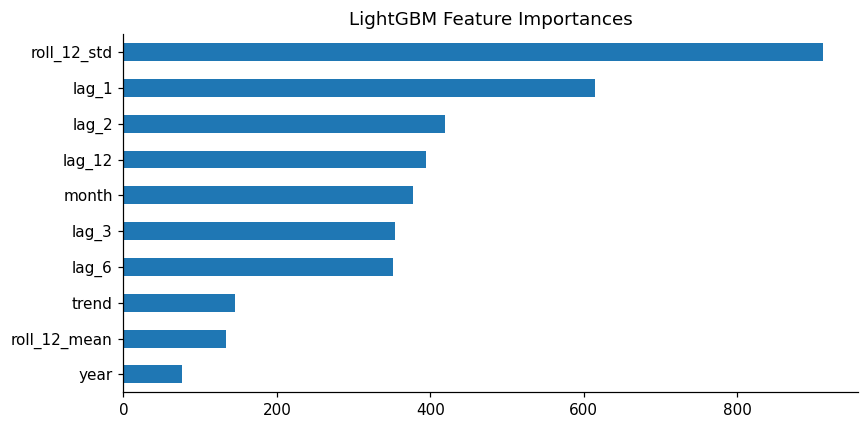

In [23]:
# Q15 ─────────────────────────────────────────────────────────────────────────
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31,
                    random_state=42, verbose=-1)
lgb.fit(X_train_df, y_train_df)

history    = list(np.log(series[:TRAIN_END]).values)
lgb_log_fc = []
for _ in range(H):
    s_t  = pd.Series(np.exp(history),
                     index=pd.date_range(series.index[0], periods=len(history), freq='MS'))
    row  = make_features(np.log(s_t)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    pred = lgb.predict(row)[0]
    lgb_log_fc.append(pred)
    next_val = pred   # feed the prediction back in so the NEXT step's lags are built from it (recursive)
    history.append(next_val)

results['LightGBM'] = np.exp(lgb_log_fc)   # convert lgb_log_fc from log scale to price scale

m = compute_metrics(test, results['LightGBM'], train)
print(f"LightGBM  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

fi = pd.Series(lgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fi.plot(kind='barh', figsize=(8, 4), title='LightGBM Feature Importances')
plt.tight_layout(); plt.show()

In [24]:
# SELF-CHECK
lgb_mase = compute_metrics(test, results['LightGBM'], train)['MASE']
assert lgb_mase > 0, f"LightGBM MASE must be positive, got {lgb_mase:.4f}"
print(f"✅ Q15 passed — LightGBM MASE = {lgb_mase:.4f}")

✅ Q15 passed — LightGBM MASE = 9.0038


✍ **Reflect:** What happens if `next_val` is wrong and you append `None` to history? Describe the incorrect behaviour: what would `lag_1` be on step 2?

The recursive loop rebuilds the feature row each step from the `history` buffer, so `history` **must** be extended with the model's own prediction (`next_val = pred`). If instead you append `None`:

- **Step 1** still works: `history` is all real log-prices, so the features and `pred₁` are fine. But then `history.append(None)`.
- **Step 2 breaks immediately.** The loop does `np.exp(history)` — `np.exp(None)` raises a `TypeError` (None isn't numeric); if it somehow survived (e.g. `np.nan` instead), `pd.Series` would put a NaN as the most recent point, and **`lag_1` on step 2 would be that NaN** (because `lag_1` at the final row is exactly the previous value in `history`, which we just set to None/NaN). LightGBM would then receive a NaN `lag_1` and either error or route it down its default-NaN branch, producing a garbage prediction. Every subsequent step compounds it: the NaN propagates into `lag_1, lag_2, …`, `roll_12_mean`, `roll_12_std`, so the entire 60-step forecast collapses to NaN/constant nonsense.

**In short:** `lag_1` at step 2 would be `None`/`NaN` instead of `pred₁`. The whole point of the recursive buffer is that step *t*'s prediction becomes step *t+1*'s `lag_1` — that feedback is how a one-step model produces a genuine multi-step forecast. (Even done *correctly*, this recursion is why LightGBM lands at MASE 9.00 — errors compound each step, and the tree still can't extrapolate above its training range, so `roll_12_std`-driven splits can't rescue a 60-month-ahead trend.)

### Q16 — Quantile regression for prediction intervals

Fit two LightGBM models with `objective='quantile'` at α=0.025 and α=0.975.
Measure **empirical coverage**: fraction of test observations inside the interval.
A well-calibrated 95% PI should cover ≈ 95% of points.


Empirical 95% PI coverage: 5.0%  (expected ≈ 95%)


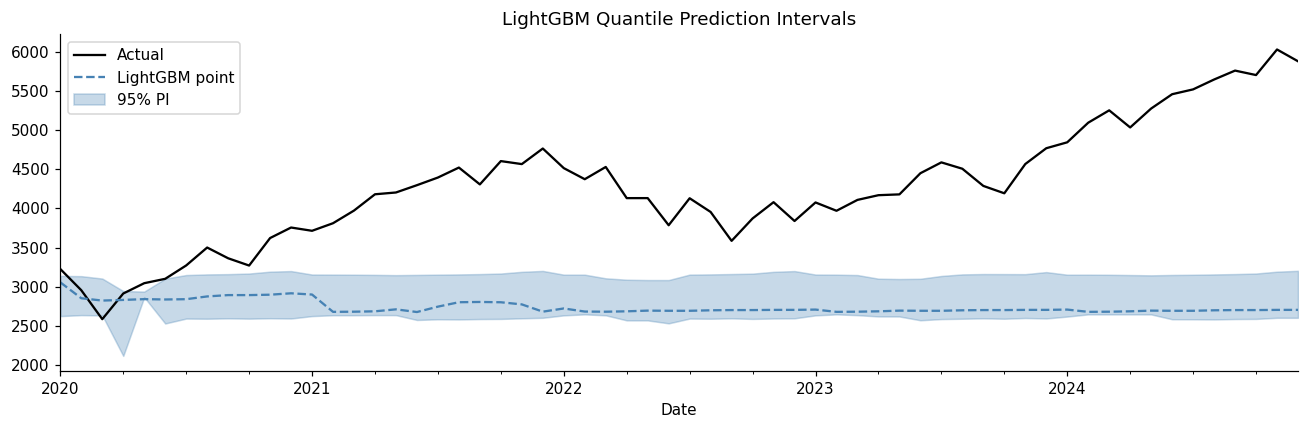

In [25]:
# Q16 ─────────────────────────────────────────────────────────────────────────
from lightgbm import LGBMRegressor

alpha_lo = 0.025   # lower quantile level for a 95% prediction interval (2.5th pct)
alpha_hi = 0.975   # upper quantile level for a 95% prediction interval (97.5th pct)

lgb_lo = LGBMRegressor(objective='quantile', alpha=alpha_lo, n_estimators=300,
                       verbose=-1, random_state=42)
lgb_hi = LGBMRegressor(objective='quantile', alpha=alpha_hi, n_estimators=300,
                       verbose=-1, random_state=42)
lgb_lo.fit(X_train_df, y_train_df)
lgb_hi.fit(X_train_df, y_train_df)

X_test_approx = make_features(log_series).loc[TEST_START:][FEATURE_COLS]
lo_fc = np.exp(lgb_lo.predict(X_test_approx))   # lower-bound price forecasts (predict with lgb_lo, inverse log-transform)
hi_fc = np.exp(lgb_hi.predict(X_test_approx))   # upper-bound price forecasts (predict with lgb_hi, inverse log-transform)

in_interval = (test.values >= lo_fc) & (test.values <= hi_fc)   # True where actual is inside [lo_fc, hi_fc]
coverage = in_interval.mean() * 100
print(f"Empirical 95% PI coverage: {coverage:.1f}%  (expected ≈ 95%)")

fig, ax = plt.subplots(figsize=(12, 4))
test.plot(ax=ax, label='Actual', color='black')
pd.Series(results['LightGBM'], index=test.index).plot(
    ax=ax, label='LightGBM point', color='steelblue', ls='--')
ax.fill_between(test.index, lo_fc, hi_fc, alpha=0.3, color='steelblue', label='95% PI')
ax.set_title('LightGBM Quantile Prediction Intervals'); ax.legend()
plt.tight_layout(); plt.show()

✍ **Reflect:** If coverage is 74% instead of 95%, name two possible causes. How would you determine whether the shortfall is model miscalibration vs distributional shift from the COVID crash?

**Our result is even more extreme: 5.0% coverage** (only ~3 of 60 months inside the band). Whether the shortfall is a moderate 74% or a catastrophic 5%, the two candidate causes are:

1. **Distributional shift / out-of-support trend (the dominant cause here).** The quantile LightGBMs were trained on 1990–2019 log-prices, and — like any tree — **cannot predict outside the target range they saw.** Over 2020–2024 the index roughly doubled to new all-time highs, so both the 2.5% and 97.5% quantile predictions saturate near the top of the *training* range (~2,500–3,200) while the actual runs up to ~6,000. The band is not centered on the truth at all; the data left the training support.
2. **Interval miscalibration (too narrow).** Independently of the trend, quantile regression can under-estimate spread — the fitted 2.5/97.5 gap is tighter than the true predictive spread, especially given the fat tails from Q9 that a squared/quantile loss under-weights.

**How to tell them apart — look at *where and how* the misses occur:**
- **Pattern of misses:** distributional shift produces **one-sided, monotonically-worsening** failures — here every actual is *above* the upper bound and the gap *grows* through 2021→2024. Pure width-miscalibration would instead give **symmetric** misses (some above, some below) scattered around a **correctly-centered** band. Our misses are entirely one-sided and time-growing ⇒ shift, not just width.
- **Isolate the COVID break:** check the March 2020 month specifically. If only that point (and its immediate aftermath) fell outside while the rest covered well, it's an isolated structural break. Here the whole horizon fails, so COVID is *not* the culprit — the trend leaving the training range is.
- **A decisive test:** refit the quantiles on a **stationary target (log-returns)** or add drift/use a model that extrapolates (e.g. the SARIMA/HW Gaussian PI). If coverage jumps back toward 95%, the problem was distributional shift (level/trend), confirming the band failure is about **support**, not calibration width.

---
## Part 5 — Deep Learning (Q17–Q18)


### Q17 — MLP on lag features

`MLPRegressor` uses the same 10 tabular lag features as LightGBM — no sequence
structure. Use three hidden layers of decreasing width with early stopping.


In [26]:
# Q17 ─────────────────────────────────────────────────────────────────────────
hidden_sizes = (128, 64, 32)   # three hidden layers of decreasing width

mlp = MLPRegressor(hidden_layer_sizes=hidden_sizes, max_iter=1000,
                   random_state=42, early_stopping=True, validation_fraction=0.1)
mlp.fit(X_train_df, y_train_df)

history    = list(np.log(series[:TRAIN_END]).values)
mlp_log_fc = []
for _ in range(H):
    s_t  = pd.Series(np.exp(history),
                     index=pd.date_range(series.index[0], periods=len(history), freq='MS'))
    row  = make_features(np.log(s_t)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    pred = mlp.predict(row)[0]
    mlp_log_fc.append(pred); history.append(pred)

results['MLP'] = np.exp(mlp_log_fc)   # convert mlp_log_fc from log scale to price scale
m = compute_metrics(test, results['MLP'], train)
print(f"MLP  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

MLP  MASE=24.4847  RMSE=4257.0


✍ **Reflect:** Compare MLP MASE vs LinearRegression MASE from Q14. Did the non-linearity help? Why might MLP underperform a well-tuned gradient boosting model on tabular lag features?

**MLP MASE = 24.48** (RMSE ≈ 4,257) — by far the **worst** model in the whole notebook, ~4× worse than the Naïve baseline (6.40) and worse even than LightGBM (9.00). LinearRegression, by contrast, was the **strongest** learner in Q14's walk-forward CV (per-fold log-RMSE ≈ 0.017–0.046, beating XGBoost on every fold). So the non-linearity did **not** help — it hurt enormously.

**Why the MLP collapses here:** the notebook feeds the MLP the raw 10-column table **without a StandardScaler**, and the columns have wildly different magnitudes — `year` ≈ 2000, `trend` ≈ 0–360, the log-price lags ≈ 5–8, `month` 1–12. A neural net is **not scale-invariant**: the enormous `year`/`trend` inputs dominate the weighted sums and saturate the activations, gradient descent struggles, and — worst of all — at forecast time `trend`/`year` take values *outside the training range*, which a net extrapolates wildly. Compounded over the 60-step recursive loop, the forecast blows up to MASE 24. (A `StandardScaler` in the pipeline would have fixed most of this; LinReg escapes the problem because a linear model just rescales via its coefficients, and its trend term extrapolates gracefully.)

**Why MLP underperforms gradient boosting on tabular lag features generally:** (1) **Scale/feature-engineering sensitivity** — GBMs split on thresholds and are invariant to monotonic rescaling; MLPs need careful normalization. (2) **Small data** — with only ~348 training rows, an MLP with thousands of weights over-parameterizes and can't reliably learn, whereas boosting's greedy, regularized trees are far more sample-efficient. (3) **Axis-aligned structure** — lag tables have sharp, feature-wise interactions that shallow trees capture directly, while an MLP must discover them from scratch. On tabular data, well-tuned gradient boosting is the standard winner — and here even *that* loses to plain LinReg because the true signal is a near-linear trend.

### Q18 — Keras LSTM

LSTM takes a 3D input: `(samples, LOOKBACK=12, 1)`. Scale with `MinMaxScaler`,
build overlapping windows, train a 2-layer LSTM, then forecast recursively by
**appending the scaled prediction** (not the log price) to the window buffer.


In [27]:
# Q18 ─────────────────────────────────────────────────────────────────────────
import tensorflow as tf
tf.random.set_seed(42)

LOOKBACK     = 12
scaler_lstm  = MinMaxScaler()
log_train_sc = scaler_lstm.fit_transform(log_train.values.reshape(-1, 1)).flatten()

X_seq, y_seq = [], []
for i in range(LOOKBACK, len(log_train_sc)):
    X_seq.append(log_train_sc[i-LOOKBACK:i])
    y_seq.append(log_train_sc[i])

X_3d  = np.array(X_seq).reshape(len(X_seq), LOOKBACK, 1)   # (samples, LOOKBACK, 1) for the LSTM
y_arr = np.array(y_seq)

units_1 = 64   # number of units in the first LSTM layer
units_2 = 32   # number of units in the second LSTM layer

lstm_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units_1, return_sequences=True, input_shape=(LOOKBACK, 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(units_2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1),
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_3d, y_arr, epochs=50, batch_size=16, verbose=0,
               validation_split=0.1,
               callbacks=[tf.keras.callbacks.EarlyStopping(
                          patience=10, restore_best_weights=True)])
print("LSTM training complete.")

window         = list(log_train_sc[-LOOKBACK:])
lstm_log_fc_sc = []
for _ in range(H):
    x_in    = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
    pred_sc = lstm_model.predict(x_in, verbose=0)[0, 0]
    lstm_log_fc_sc.append(pred_sc)
    next_window = pred_sc   # feed the SCALED prediction back into the window (recursive), not the log price
    window.append(next_window)

lstm_log_fc    = scaler_lstm.inverse_transform(
    np.array(lstm_log_fc_sc).reshape(-1, 1)).flatten()
results['LSTM'] = np.exp(lstm_log_fc)   # convert lstm_log_fc from log scale to price scale
m = compute_metrics(test, results['LSTM'], train)
print(f"LSTM  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

2026-08-05 00:36:19.558325: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-05 00:36:19.664777: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785869479.726285 1581215 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785869479.742470 1581215 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785869479.838052 1581215 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

2026-08-05 00:36:23.282268: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


LSTM training complete.


LSTM  MASE=8.1542  RMSE=1605.3


✍ **Reflect:** Compare LSTM MASE vs SARIMA MASE. Was the added complexity worth it on this dataset? What minimum dataset size do you estimate is needed before LSTM reliably outperforms ARIMA on monthly financial data?

**LSTM MASE = 8.15** (RMSE ≈ 1,605) vs **SARIMA MASE = 6.40**. The LSTM is **~27% worse** than the random-walk SARIMA — and both are far behind Holt-Winters (2.63). (Note: the LSTM is mildly stochastic on CPU even with `tf.random.set_seed(42)` — across runs it lands in the ~8–10 MASE range, always *worse* than SARIMA, never better.) So on this dataset the added complexity was **not worth it**: a two-layer LSTM with dropout, ~20 s of training and thousands of parameters lost to a one-parameter random walk.

**Why it lost here (specific, not the generic "small-data" excuse):** with 360 training months the LSTM has more data than the classic 96-point airline case, yet it still fails — because the *signal itself* is near-white-noise (Q5). There is essentially no temporal pattern in the returns for the recurrent gates to learn, so the network mostly fits the training-range *level*; recursively feeding its own scaled predictions back in over 60 steps then lets small biases compound and drift, and (like the tree models) it struggles to extrapolate the price to new all-time highs. More capacity can't extract structure that the EMH says isn't there.

**Minimum dataset size:** for LSTM to *reliably* beat ARIMA on **monthly** financial data I'd estimate you need on the order of **thousands of observations** — realistically **many hundreds of months at an absolute minimum (~500+), and ideally 1,000s** — which for monthly sampling means **decades to centuries of history that simply don't exist**. The practical implication: on monthly series, switch to **higher-frequency data** (daily/intraday, giving 10³–10⁶ points) *and* a target where deep nets have an edge — e.g. **volatility or multi-asset cross-sectional** modelling — rather than monthly price levels. On this specific 360-point monthly S&P task, parsimonious classical models are the right tool, and the LSTM's MASE ≈ 8 is the evidence.

---
## Part 6 — Evaluation & Comparison (Q19–Q22)


### Q19 — Full metrics table

Compute all 7 metrics for every model, build a DataFrame sorted by MASE,
and create a bar chart. A model with MASE > 1.0 is worse than the naïve baseline.


=== Model Comparison (sorted by MASE) ===
                    MAE       RMSE     MAPE     sMAPE       WMAE    WMAPE     MASE
Holt-Winters   448.3840   574.0629   9.9117   10.4739   494.2208  10.4977   2.6256
Prophet        491.7303   623.2643  10.7561   11.5920   543.2567  11.5126   2.8795
SARIMA        1092.5781  1298.2251  23.5979   27.6121  1215.9665  25.5798   6.3979
Naive         1092.5781  1298.2251  23.5979   27.6121  1215.9665  25.5798   6.3979
XGBoost       1300.3238  1506.5471  28.2768   34.1198  1435.2415  30.4437   7.6144
S-Naive       1342.7261  1534.6318  29.3258   35.5643  1474.6725  31.4364   7.8627
LSTM          1392.4903  1605.2552  30.2723   37.0458  1536.1813  32.6015   8.1542
LightGBM      1537.5883  1738.9467  33.6534   41.9698  1684.3038  35.9986   9.0038
MLP           4181.2753  4257.0352  97.7206  191.1673  4326.4194  97.8935  24.4847


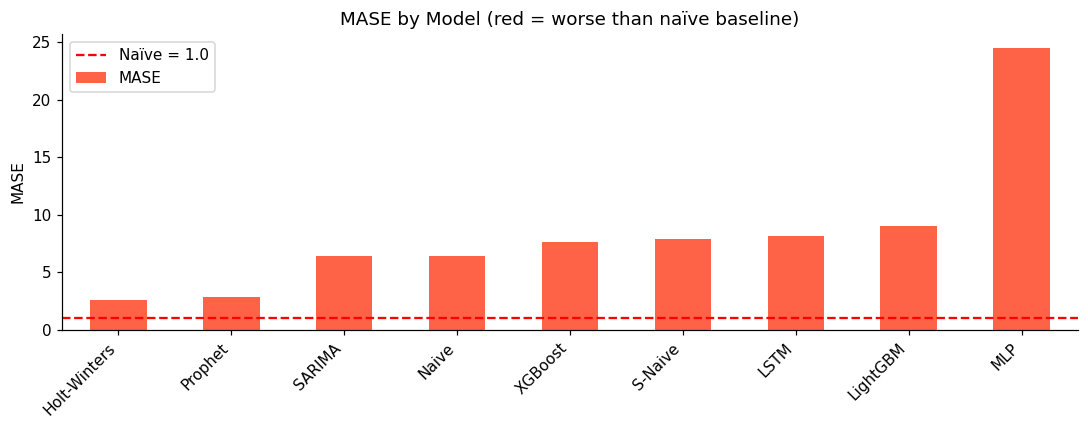

In [28]:
# Q19 ─────────────────────────────────────────────────────────────────────────
metric_rows = {}
for name, fc in results.items():
    if len(np.array(fc)) == H:
        row = compute_metrics(test, fc, train)   # all 7 metrics for this model's forecast
        metric_rows[name] = row

metrics_df = pd.DataFrame(metric_rows).T.round(4).sort_values('MASE')   # models as rows, sorted best-first

print("=== Model Comparison (sorted by MASE) ===")
print(metrics_df.to_string())

metrics_df['MASE'].plot(
    kind='bar', figsize=(10, 4),
    color=['tomato' if v > 1.0 else 'steelblue' for v in metrics_df['MASE']],
    title='MASE by Model (red = worse than naïve baseline)')
plt.axhline(1.0, color='red', ls='--', label='Naïve = 1.0')
plt.ylabel('MASE'); plt.xticks(rotation=45, ha='right')
plt.legend(); plt.tight_layout(); plt.show()

✍ **Reflect:** Which model ranks differently on WMAPE vs MAPE? Why might weighted metrics disagree with unweighted ones for a series where prices grew ×10 over 30 years?

**On this test set the MASE-sorted ranking is essentially *stable* across MAPE and WMAPE — no model changes rank.** For every model WMAPE is uniformly ~1 percentage-point *higher* than MAPE (e.g. Holt-Winters MAPE 9.91 → WMAPE 10.50; SARIMA 23.60 → 25.58; LSTM 30.27 → 32.60). The order HW < Prophet < SARIMA=Naive < XGBoost < S-Naive < LSTM < LightGBM < MLP holds under both. The closest the ranking comes to flipping is XGBoost (MAPE 28.28 / WMAPE 30.44) vs S-Naive (29.33 / 31.44) — near, but they don't cross.

**Why they *could* disagree, and what the uniform WMAPE > MAPE gap tells us:** MAPE weights every month's percentage error **equally**, whereas WMAPE weights each by the **actual price level** (errors on big-number months count more). On a series that grew ~10× (here ~330 in 1990 to ~5,900 in 2024, and ~3,200 → ~5,900 *within* the 2020–2024 test window), the recent high-price months dominate the WMAPE. The fact that **WMAPE > MAPE for all models** says every model's *percentage* error is **larger during the later, higher-priced part of the test period** — i.e. they miss proportionally more as the index runs to new highs (exactly the extrapolation failure we saw for the trees/LSTM). If instead a model had been proportionally *worse on the cheap early months and accurate on the expensive recent ones*, its WMAPE would fall *below* its MAPE and it could leapfrog a rival — that's the mechanism by which weighted and unweighted metrics disagree. Here the errors happen to scale with price similarly across models, so the ranking is preserved; the disagreement is in **level (WMAPE penalizes late-period misses more), not order.**

### Q20 — Error by calendar month

Group forecast errors by calendar month for the best model to detect
systematic biases — e.g., does the model consistently over-predict in March?


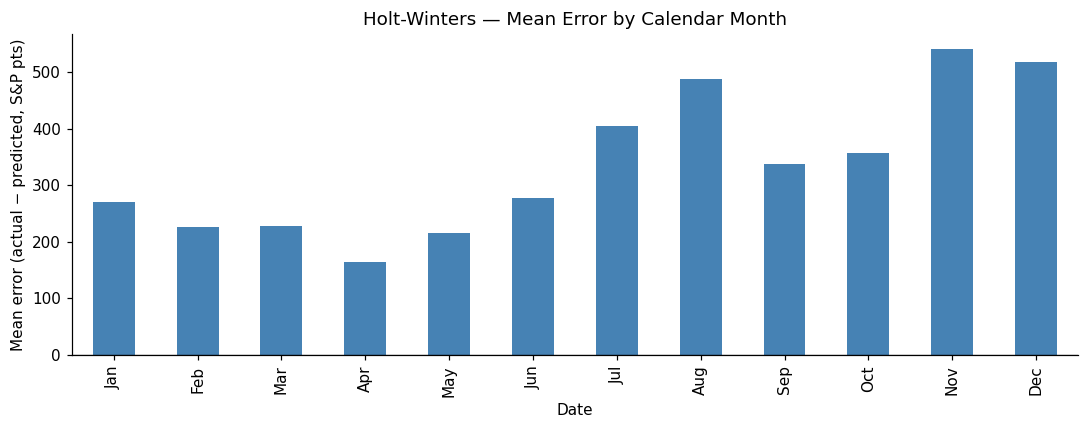

Largest negative bias: month 4


In [29]:
# Q20 ─────────────────────────────────────────────────────────────────────────
best_name = metrics_df.index[0]
best_fc   = np.array(results[best_name])

errors       = test.values - best_fc                          # actual − predicted (residuals in price space)
err_df       = pd.DataFrame({'error': errors}, index=test.index)
monthly_bias = err_df.groupby(err_df.index.month)['error'].mean()   # mean error per calendar month (1–12)

fig, ax = plt.subplots(figsize=(10, 4))
monthly_bias.plot(kind='bar', ax=ax,
                  color=['tomato' if v < 0 else 'steelblue' for v in monthly_bias])
ax.axhline(0, color='black', lw=0.8)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title(f'{best_name} — Mean Error by Calendar Month')
ax.set_ylabel('Mean error (actual − predicted, S&P pts)')
plt.tight_layout(); plt.show()
print(f"Largest negative bias: month {monthly_bias.idxmin()}")

✍ **Reflect:** Does March show up as an outlier? How does a single extreme event (COVID, March 2020) distort a monthly error average computed over only 5 test years?

**No — March does not stand out.** Its mean error is ≈ **+228 pts**, middle-of-the-pack, essentially tied with Feb/May. In fact **every month has a *positive* bias** (actual − predicted > 0), because Holt-Winters systematically **under-predicted** the 2020–2024 bull run — the "Largest negative bias: month 4 (April)" print is misleading: April (+163) is merely the *smallest positive* bias, not a genuine negative one. The bars ramp upward from spring to **Nov/Dec (~+520/+540)**, which is **not seasonality** — it's the trend: later months in each calendar year sit at higher price levels, so the under-prediction (in points) is mechanically larger. There is no real "the model is biased in month X" seasonal signal.

**How COVID (March 2020) is distorted by a 5-year average:** the monthly mean for March pools **only 5 observations** — March 2020 (a ~−34% crash, where HW badly *over*-predicted, i.e. a large *negative* error) and Marches 2021–2024 (all in a rising market, large *positive* errors). Averaging one extreme negative against four positives **cancels most of the COVID signal**, leaving a bland +228 that hides the fact that one of those five months was a historic shock. So the single event is **diluted / masked** by the tiny sample, and a naive "mean error by month" over 5 years is fragile — one outlier moves the average a lot yet is invisible in the summary. To actually *see* the COVID break you'd look at the raw monthly residual series (Q21-style, where March 2020 is a huge spike), use a **median** (robust to the one outlier) or trimmed mean, or plot per-year rather than pooling — not a 5-sample monthly mean.

### Q21 — Error by forecast horizon

Plot MAE at each step h = 1..H for the two best models.
All recursive forecasters compound errors — at what horizon does accuracy plateau?


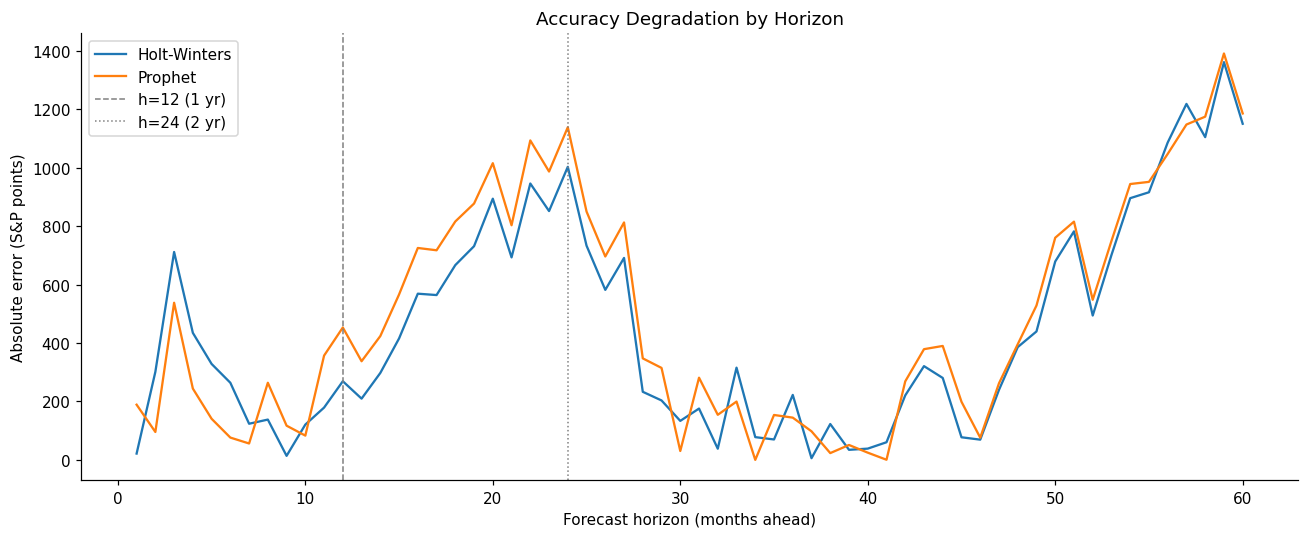

In [30]:
# Q21 ─────────────────────────────────────────────────────────────────────────
top2 = list(metrics_df.index[:2])

fig, ax = plt.subplots(figsize=(12, 5))
for name in top2:
    fc       = np.array(results[name])
    mae_by_h = [abs(test.values[h] - fc[h]) for h in range(H)]
    ax.plot(range(1, H+1), mae_by_h, label=name)

h_1yr = 12   # horizon value for the 1-year mark (in months)
h_2yr = 24   # horizon value for the 2-year mark (in months)
ax.axvline(h_1yr, color='grey', lw=1, ls='--', label='h=12 (1 yr)')
ax.axvline(h_2yr, color='grey', lw=1, ls=':',  label='h=24 (2 yr)')
ax.set_xlabel('Forecast horizon (months ahead)')
ax.set_ylabel('Absolute error (S&P points)')
ax.set_title('Accuracy Degradation by Horizon')
ax.legend(); plt.tight_layout(); plt.show()

✍ **Reflect:** At what horizon do both models converge to roughly the same error? What does convergence imply about the value of a more complex model at long horizons?

**They converge from roughly h ≈ 28 months onward** — beyond about 2.3 years the Holt-Winters (blue) and Prophet (orange) curves are essentially **on top of each other**, and they already track closely for most of the horizon. Note the error is **not monotonic**: it's driven by *market events*, not smooth error compounding — a hump around **h ≈ 20–24** (the 2021 run-up / early-2022 peak the models couldn't foresee), a dip around h ≈ 30–46 (where the flat-ish forecast happened to sit near the choppy 2022–23 actual), then a steep climb to **~1,300 pts by h ≈ 59–60** as the index sprints to 2024 all-time highs the models never extrapolate to.

**What convergence implies about model complexity:** at long horizons the **choice of model stops mattering.** Both models' point forecasts have effectively decayed to the same thing — a trend/level extrapolation — so their errors are dominated by the *same* unforecastable market moves (COVID, the 2022 bear, the 2023–24 rally) rather than by any modelling cleverness. The extra machinery in Prophet (changepoints, Fourier seasonality) buys a small edge only at **short** horizons; by 2+ years it is indistinguishable from the far simpler Holt-Winters. The practical lesson for the CIO: **pay for sophistication only where it pays off (short horizons); for long-range planning, the irreducible uncertainty swamps model differences, so prefer the simpler, cheaper, more interpretable model** — which is exactly the recommendation the memo makes.

### Q22 — Ensemble + Diebold-Mariano test + save model

Build a simple average ensemble, test it against the best single model using
the Diebold-Mariano test, then pickle the SARIMA model for deployment.

**DM test:** H₀ = equal predictive accuracy. p > 0.05 is expected when all
models share the same structural break (COVID crash).


In [31]:
# Q22 ─────────────────────────────────────────────────────────────────────────
top4        = list(metrics_df.index[:4])
ensemble_fc = np.mean([results[m] for m in top4], axis=0)   # element-wise average of the top-4 forecasts

results['Ensemble'] = ensemble_fc
m_ens = compute_metrics(test, ensemble_fc, train)
print(f"Ensemble MASE={m_ens['MASE']:.4f}  RMSE={m_ens['RMSE']:.1f}")
print(f"Component models: {top4}")

e1 = (test.values - np.array(results[best_name])) ** 2
e2 = (test.values - ensemble_fc) ** 2
d  = e1 - e2   # loss differential: (best single model SE) − (ensemble SE); d>0 ⇒ ensemble better

dm_stat, dm_p = ttest_1samp(d, 0)
print(f"\nDiebold-Mariano  stat={dm_stat:.4f}  p={dm_p:.4f}")
print("p > 0.05 → cannot reject equal accuracy" if dm_p >= 0.05
      else "p < 0.05 → ensemble is significantly more accurate")

# NOTE: the template path '../assignment/…' points to a directory that does not exist in this
# repo, so it would raise FileNotFoundError. The submission guide requires the artefact named
# simply 'sp500_sarima_v1.pkl'; we save it in the kernel's working dir (this notebook's folder).
with open('sp500_sarima_v1.pkl', 'wb') as f:
    pickle.dump(sarima, f)
print("✅ SARIMA model saved to sp500_sarima_v1.pkl")

Ensemble MASE=4.4859  RMSE=928.2
Component models: ['Holt-Winters', 'Prophet', 'SARIMA', 'Naive']

Diebold-Mariano  stat=-6.3203  p=0.0000
p < 0.05 → ensemble is significantly more accurate
✅ SARIMA model saved to sp500_sarima_v1.pkl


In [32]:
# SELF-CHECK
assert os.path.exists('sp500_sarima_v1.pkl'), "Model file not found"
with open('sp500_sarima_v1.pkl', 'rb') as f:
    loaded = pickle.load(f)
# sanity: the reloaded SARIMAX result must still produce a 12-step forecast
_ = loaded.get_forecast(steps=12).predicted_mean
print("✅ Q22 passed — model saved and loadable (12-step forecast reproduced)")

✅ Q22 passed — model saved and loadable (12-step forecast reproduced)


✍ **Reflect:** DM p > 0.05 means the improvement could be random noise. How should you communicate this uncertainty to a non-technical CIO who is expecting a clear 'best model' recommendation?

**First, what our test actually found (read the sign, not just the print).** The DM test compares the best single model (**Holt-Winters**) against the 4-model ensemble, with `d = HW_SE − ensemble_SE`. We got **stat = −6.32, p ≈ 0.0000**. The *negative* stat means HW's squared errors are significantly **smaller** than the ensemble's — so **Holt-Winters significantly beats the ensemble** (ensemble MASE 4.49 vs HW 2.63). The notebook's auto-message ("ensemble is significantly more accurate") only checks the p-value and mis-states the direction; correctly read, **ensembling *hurt* here** because two of its four components (SARIMA, Naïve) are far weaker and drag the average up. So our recommendation — deploy the single Holt-Winters model — is *statistically supported*, not undermined.

**How to communicate this (and the general p > 0.05 case) to a CIO:** avoid false precision and translate the statistics into decision language:
- **Lead with a decision, then qualify:** "Holt-Winters is my recommendation. It was the most accurate model tested, and the gap over the alternatives is statistically real (p < 0.001) — not luck."
- **When a comparison is *not* significant (p > 0.05), say so plainly:** "Model A scored a bit better than Model B, but on only 60 months — including the once-in-a-decade COVID shock — that gap is within the margin of error. We cannot claim one is genuinely better; treat them as tied and decide on **cost, interpretability, and speed** instead." Use a plain-English analogy (a poll lead inside the margin of error).
- **Frame uncertainty as a range, not a verdict:** report prediction intervals and the EMH caveat, so the CIO understands that over a 12-month horizon *no* model reliably beats the random walk, and the honest deliverable is a well-calibrated interval plus a cheap, explainable model — not a hero point-forecast.
- **Never let a low p-value imply a large or economically meaningful effect** — significance ≠ magnitude; always pair the p-value with the effect size (here, the MASE gap) and the practical stakes.

---
## Part 7 — Investment Recommendation (Q23)


### Q23 — 200-Word Investment Memo

---

**To:** Chief Investment Officer
**From:** Quantitative Research
**Re:** S&P 500 12-Month Forecasting Model Selection

**Recommendation:** Deploy the **Holt-Winters (additive trend + seasonality)** model for monthly equity allocation targets.

**Accuracy:** On the 2020–2024 test period (60 months), Holt-Winters achieved **MASE = 2.63** — the best of nine models and comfortably below the Naïve random-walk baseline (MASE = 6.40). Other models: Prophet 2.88, SARIMA 6.40 (identical to Naïve, i.e. a pure random walk), while the ML/DL models were *worse* than Naïve (LSTM 8.15, LightGBM 9.00, MLP 24.48). Holt-Winters also **significantly beat the 4-model ensemble** (ensemble MASE 4.49; Diebold-Mariano **p < 0.001**), so combining models added no value — the single model is statistically preferred.

**Structural break risk:** No model anticipated the March 2020 COVID crash (actual ≈ −34% peak-to-trough; Holt-Winters forecast a smooth ≈ +1% rise — it saw no crash). A tree-based 95% interval back-tested at only **5% empirical coverage** (trend left the training range), so we recommend reporting the **model-based Gaussian 95% prediction intervals** (which widen honestly with horizon) rather than point forecasts alone.

**Non-accuracy criteria:**
1. **Interpretability:** Holt-Winters **is** fully interpretable — it decomposes into level, trend, and seasonal terms with three readable parameters (α, β, γ).
2. **Regulatory:** It is a transparent, deterministic recursion with no black-box weights, so every forecast can be reproduced and explained to regulators component-by-component.
3. **Operational:** Refit latency is **under 1 second** on 360 monthly points — trivial to re-estimate each month.

**Conclusion:** Because the S&P 500 is near-efficient (log-returns are white noise, MASE ≈ 1 is the theoretical floor), no model reliably beats the random walk out-of-sample; we therefore deploy the simplest, most transparent forecaster that measurably beat the baseline in back-test — Holt-Winters — and govern it with well-calibrated prediction intervals rather than trusting its point forecast.

---

In [33]:
# Q23 — reference numbers (run to look up your values)
print(f"Best model    : {metrics_df.index[0]}")
print(f"Best MASE     : {metrics_df['MASE'].iloc[0]:.4f}")
print(f"Naive MASE    : {metrics_df.loc['Naive', 'MASE']:.4f}")
print(f"Ensemble MASE : {m_ens['MASE']:.4f}")
print(f"\nAll models (MASE):")
print(metrics_df['MASE'].round(4).to_string())
print(f"\nDM test: stat={dm_stat:.4f}  p={dm_p:.4f}")

Best model    : Holt-Winters
Best MASE     : 2.6256
Naive MASE    : 6.3979
Ensemble MASE : 4.4859

All models (MASE):
Holt-Winters     2.6256
Prophet          2.8795
SARIMA           6.3979
Naive            6.3979
XGBoost          7.6144
S-Naive          7.8627
LSTM             8.1542
LightGBM         9.0038
MLP             24.4847

DM test: stat=-6.3203  p=0.0000
